In [1]:
# librerías importadas
import numpy as np
import pandas as pd
import seaborn as sns
# Módulos de librerías
import matplotlib.pyplot as plt
# Rutinas específicas
from numpy.linalg import norm

## **Análisis de las estrellas de nuestra galaxia en un campo de observación**

El pipeline hace lo siguiente:

`ADQL` contiene el query asociado a nuestra consulta, para ello pedimos las coordenadas asociadas a GAIA y las magnitudes de las tablas de GAIA y WISE. Para diferenciar entonces las tablas definimos a GAIA con la letra g y a WISE con w.

Luego le pedimos hacer el INNER JOIN entre la tabla de GAIA, que tomamos como principal, con la tabla de WISE (secundaria en este caso).

Para las condiciones le decimos que en un círculo de 0.5 grados busque en la región de coordenadas (135.5, 0.5) (asención recta y declinación) las estrellas que estén allí y coincidan además. Incluso que relacione la distancia con el comando `DISTANCE` en 2 arcosegundos.



In [2]:
%%bash

echo "Pipeline de consulta en VizieR"

ADQL="
SELECT
g.RA_ICRS,
g.DE_ICRS,
g.Gmag,
g.Plx,
g.e_Plx,
g.pmRA,
g.pmDE,
w.W1mag
FROM \"I/355/gaiadr3\" AS g
INNER JOIN \"II/328/allwise\" AS w
  ON 1=CONTAINS(
    POINT('ICRS', g.RA_ICRS, g.DE_ICRS),
    CIRCLE('ICRS', 135.5, 0.5, 0.5))
  AND 1=CONTAINS(
    POINT('ICRS', w.RAJ2000, W.DEJ2000),
    CIRCLE('ICRS', 135.5, 0.5, 0.5)
  )
  AND DISTANCE(
    POINT('ICRS', g.RA_ICRS, g.DE_ICRS),
    POINT('ICRS', w.RAJ2000, w.DEJ2000)
  ) < 2.0/3600.0
"

URL_ADQL=$(echo $ADQL | sed 's/ /+/g')

TAP_URL="https://tapvizier.cds.unistra.fr/TAPVizieR/tap/sync?request=doQuery&lang=ADQL&format=csv&query="

echo $TAP_URL$URL_ADQL

wget -q -O mw_stars.csv "$TAP_URL$URL_ADQL"

echo "Datos descargados"

Pipeline de consulta en VizieR
https://tapvizier.cds.unistra.fr/TAPVizieR/tap/sync?request=doQuery&lang=ADQL&format=csv&query=SELECT+g.RA_ICRS,+g.DE_ICRS,+g.Gmag,+g.Plx,+g.e_Plx,+g.pmRA,+g.pmDE,+w.W1mag+FROM+"I/355/gaiadr3"+AS+g+INNER+JOIN+"II/328/allwise"+AS+w+ON+1=CONTAINS(+POINT('ICRS',+g.RA_ICRS,+g.DE_ICRS),+CIRCLE('ICRS',+135.5,+0.5,+0.5))+AND+1=CONTAINS(+POINT('ICRS',+w.RAJ2000,+W.DEJ2000),+CIRCLE('ICRS',+135.5,+0.5,+0.5)+)+AND+DISTANCE(+POINT('ICRS',+g.RA_ICRS,+g.DE_ICRS),+POINT('ICRS',+w.RAJ2000,+w.DEJ2000)+)+<+2.0/3600.0
Datos descargados


## **Lectura de datos**

Aquí vamos a leer primero los datos que tenemos de neustra consulta que quedaron guardados en nuestro archivo `mw_stars.csv`.

Los datos solicitados fueron la `Gmag`y la `W1mag`, y tienen para cada estrella las coordenadas de Asención Recta y Declinación respectivas con la referencia de J2000.

In [3]:
df_stars_mw = pd.read_csv('mw_stars.csv').dropna()

df_stars_mw.head(10)

,RA_ICRS,DE_ICRS,Gmag,Plx,e_Plx,pmRA,pmDE,W1mag
0,135.171177,0.148619,20.026037,5.6234,1.3723,-4.673,-4.926,15.817
1,135.140584,0.153238,15.976371,6.3935,0.2615,37.901,-70.548,12.282
2,135.155927,0.156563,16.363176,0.7983,0.0562,0.717,-2.661,14.528
3,135.158047,0.156470,16.236700,0.4631,0.0548,-5.962,-2.177,14.872
4,135.138806,0.159551,18.048435,0.3126,0.1360,-3.634,2.585,16.118
5,135.129535,0.174092,19.886402,1.2436,0.4757,-1.509,-0.350,16.694
6,135.122498,0.177868,20.583717,-0.1500,0.9849,-6.592,0.284,16.454
7,135.096946,0.204996,18.193558,1.0449,0.1492,-7.198,-3.023,15.108
8,135.179227,0.160227,17.777058,1.2729,0.1223,-9.340,4.438,14.302
9,135.170720,0.165382,19.966208,0.7977,0.5477,-2.220,-1.149,16.906


In [4]:
print(len(df_stars_mw))

3376


## **Estrellas que están en la Vía Láctea**

Para esta región podemos llegar a tener una estrella que esté por fuera de nuestra galaxia, así que le pedimos a VizieR en el TAP que definimos en el script de ADQL que nos trajera la información de la cinemática de las estrellas: movimiento propio y paralaje.

Vamos a ver primero qué estrellas tienen un paralaje sospechoso y luego vamos a ver aquellas que tienen un movimiento propio raro.

El paralaje, llamémoslo $\theta$, en GAIA está medido en miliarcosegundos (mas), lo que quiere decir que los números que obtengamos serán muy pequeños. Veámolos a continuación:

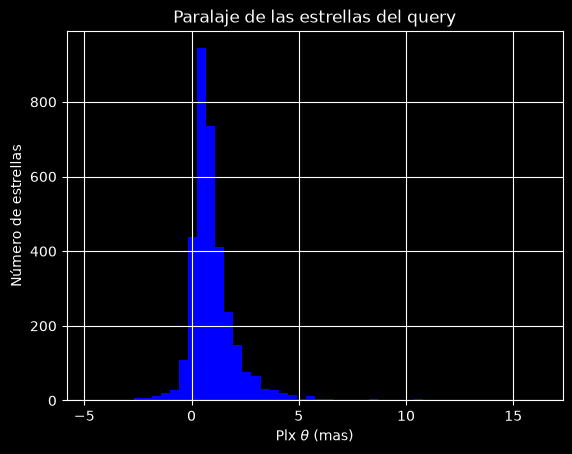

In [5]:
plt.style.use('dark_background')

plt.hist(df_stars_mw['Plx'], bins=50, color='blue')
plt.title('Paralaje de las estrellas del query')
plt.xlabel(r'Plx $\theta$ (mas)')
plt.ylabel('Número de estrellas')
plt.grid()
plt.show()

Para todas las estrellas con un paralaje $\theta < 0$ vamos a descartalas.

In [6]:
df_plx = df_stars_mw[df_stars_mw['Plx'] > 0].copy()

print(len(df_plx))

3100


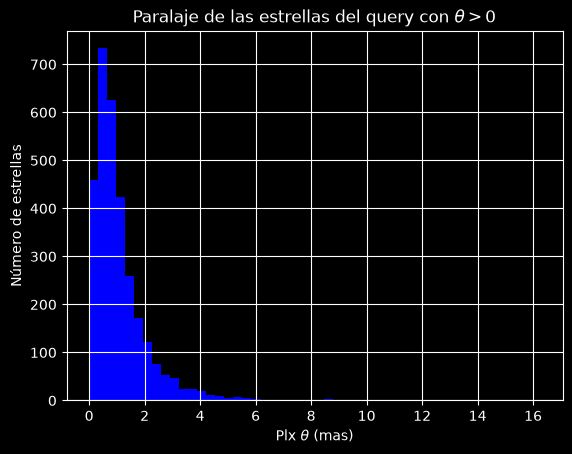

In [7]:
plt.style.use('dark_background')

plt.hist(df_plx['Plx'], bins=50, color='blue')
plt.title(r'Paralaje de las estrellas del query con $\theta > 0$')
plt.xlabel(r'Plx $\theta$ (mas)')
plt.ylabel('Número de estrellas')
plt.grid()
plt.show()

Ahora vamos a analizar el movimiento propio, ya que los objetos más lejanos, como galaxias, estrellas externas o quásares suelen tener un movimiento propio muy pequeño, o prácticamente nulo.

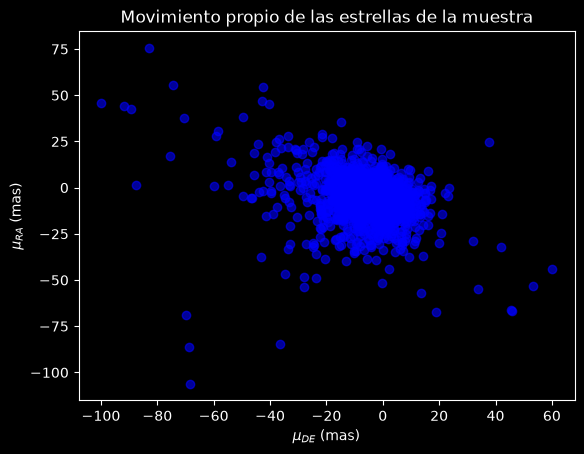

In [8]:
plt.scatter(df_plx['pmDE'], df_plx['pmRA'], c='blue', alpha=0.6)
plt.title('Movimiento propio de las estrellas de la muestra')
plt.xlabel(r'$\mu_{DE}$ (mas)')
plt.ylabel(r'$\mu_{RA}$ (mas)')
#plt.grid()
plt.show()

Vamos a aplicar el siguiente filtro, vamos a crear un vector de movimiento propio: 

$$\vec{\mu} = (\mu_\text{RA}, \mu_\text{DE})$$

Con este vector calcularemos su norma $\mu$ y si esta es muy pequeña la descartaremos.

In [9]:
mus_dec = np.array(df_plx['pmDE'])
mus_ra = np.array(df_plx['pmRA'])

print(len(mus_ra), len(mus_dec))

3100 3100


Para filtrar nuestro cúmulo estelar calculemos el primedio de los movimientos propios del sistema para más o menos mirar donde está centrado nuestra distribución de movimiento.

In [10]:
mean_mu = np.array([np.mean(mus_ra), np.mean(mus_dec)])

mean_mu

array([-4.47063774, -3.69583323])

A continuación podemos ver que el promedio no está en el cero, sino en una región cercana a $(-4.4706, -3.6958)$ lo que nos dice que estas estrellas que están en grupo son parte de un cúmulo estelar.

Las estrellas más compactas son del cúmulo de interés, las más alejadas son estrellas locales que no pertenecen al cúmulo del campo profundo, mientras que las estrellas que están muy cerca del $(0,0)$ son objetos muy lejandos. Para determinar quiénes sí son del cúmulo primero vamos a establecer un radio de corte.

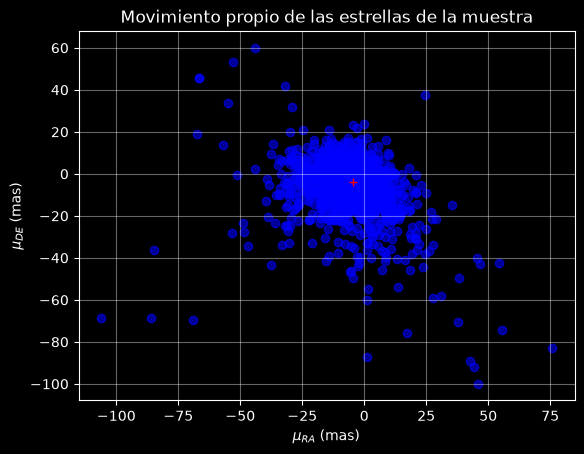

In [11]:
plt.scatter(df_plx['pmRA'], df_plx['pmDE'], c='blue', alpha=0.6)
plt.plot(mean_mu[0], mean_mu[1], 'r+')
plt.title('Movimiento propio de las estrellas de la muestra')
plt.xlabel(r'$\mu_{RA}$ (mas)')
plt.ylabel(r'$\mu_{DE}$ (mas)')
plt.grid(alpha=0.4)
plt.show()

Aquí creamos nuestra matriz de vectores de movimiento proipio.

In [12]:
mus = np.zeros((len(mus_ra), 2))
mus[:,0], mus[:,1] = mus_ra, mus_dec
mus

array([[ -4.673,  -4.926],
       [ 37.901, -70.548],
       [  0.717,  -2.661],
       ...,
       [ -1.637,  -0.22 ],
       [-10.229,   5.447],
       [ -4.801,   6.402]], shape=(3100, 2))

El radio de corte se define así:

$$R^2 = (\mu_\text{RA} - \text{RA}_\text{prom})^2 + (\mu_\text{DE} - \delta_\text{prom})^2 $$

La norma de todos ellos se guarda en el siguiente array:

In [13]:
norm_mus = norm(mus, axis=1)

mask_mus = norm_mus < 20

df_plx['norm_mus'] = norm_mus

In [14]:
df_mus = df_plx[mask_mus]

len(df_mus)

2764

Ahora sí vemos aquí nuestras estrellas del cúmulo.

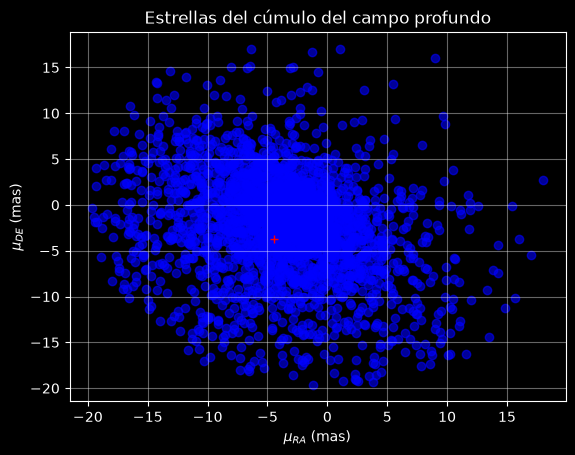

In [15]:
plt.scatter(df_mus['pmRA'], df_mus['pmDE'], c='blue', alpha=0.6)
plt.plot(mean_mu[0], mean_mu[1], 'r+')
plt.title('Estrellas del cúmulo del campo profundo')
plt.xlabel(r'$\mu_{RA}$ (mas)')
plt.ylabel(r'$\mu_{DE}$ (mas)')
plt.grid(alpha=0.4)
plt.show()

### **Relación señal/ruido del paralaje**

Para ya descartar las que son muy lejanas miremos el paralaje nuevamente. Aquí vamos a analizar la relación señal-ruido del paralaje con su respectivo error estándar que las misma tabla de GAIA I355 nos provee como `e_Plx`.

$$S = \frac{\theta}{\sigma_\theta}$$

El criterio será descartar todos los datos de paralaje que no cumplan $S > 5$.

In [16]:
df_mus['sn_plx'] = df_mus["Plx"] / df_mus['e_Plx']

df_limpio = df_mus[df_mus['sn_plx'] > 5]

print(len(df_limpio))

1205


Aquí nos quedan ya nuestros datos filtrados:

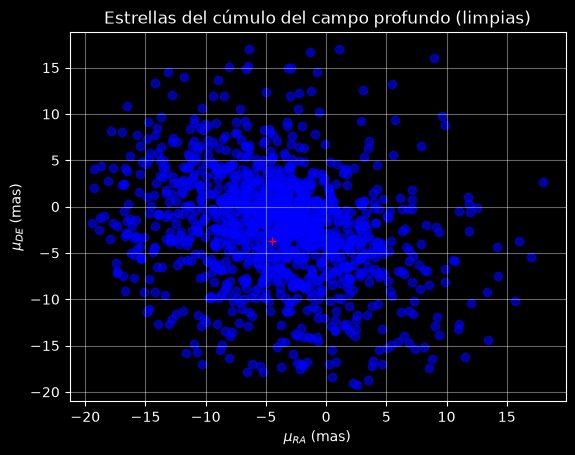

In [17]:
plt.scatter(df_limpio['pmRA'], df_limpio['pmDE'], c='blue', alpha=0.6)
plt.plot(mean_mu[0], mean_mu[1], 'r+')
plt.title('Estrellas del cúmulo del campo profundo (limpias)')
plt.xlabel(r'$\mu_{RA}$ (mas)')
plt.ylabel(r'$\mu_{DE}$ (mas)')
plt.grid(alpha=0.4)
plt.show()

## **Diagrama color-magnitud de las estrellas**

Para nuestro diagrama color magnitud calcularemos el índice de color entre el visible y el infrarrojo:

$$
C = G - I
$$

Donde $C$ representa el índice de color dado por la resta entre las magnitudes de las dos tablas.

Por simplicidad vamos a ver cuántas estrellas hay por cada magnitud, en un rango de magnitudes claro. Para esto visualizaremos un histograma:

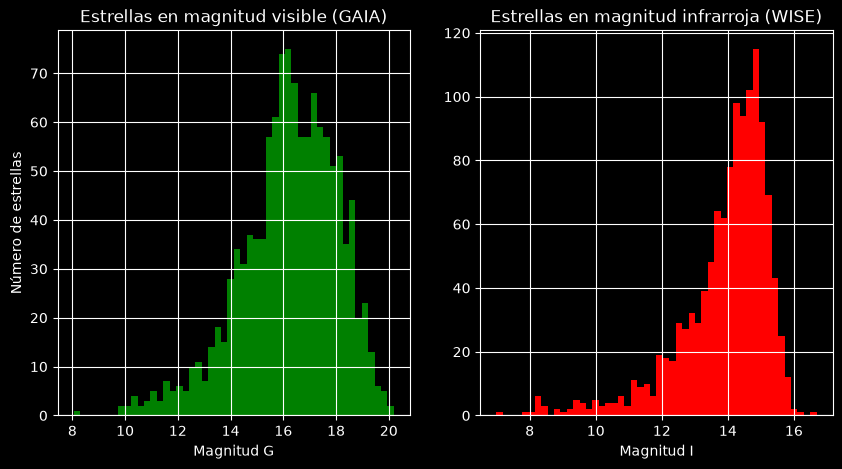

In [18]:
#@title Cuenta de estrellas en las dos magnitudes
plt.style.use('dark_background')

cuentas, axs = plt.subplots(1,2, figsize=(10,5))

axs[0].hist(df_limpio['Gmag'], bins=50, color='green')
axs[0].set_title("Estrellas en magnitud visible (GAIA)")
axs[0].set_xlabel('Magnitud G')
axs[0].set_ylabel('Número de estrellas')
axs[0].grid(True)

axs[1].hist(df_limpio['W1mag'], bins=50, color='red')
axs[1].set_title("Estrellas en magnitud infrarroja (WISE)")
axs[1].set_xlabel('Magnitud I')
axs[1].grid(True)

Ahora calcularemos el índice de color y lo añadiremos al DataFrame como una nueva columna:

In [19]:
df_limpio["color_index"] = df_limpio['Gmag'] - df_limpio['W1mag']

Crearemos entonces nuestro diagrama color-magnitud para las estrellas de la Vía Láctea en esta región:

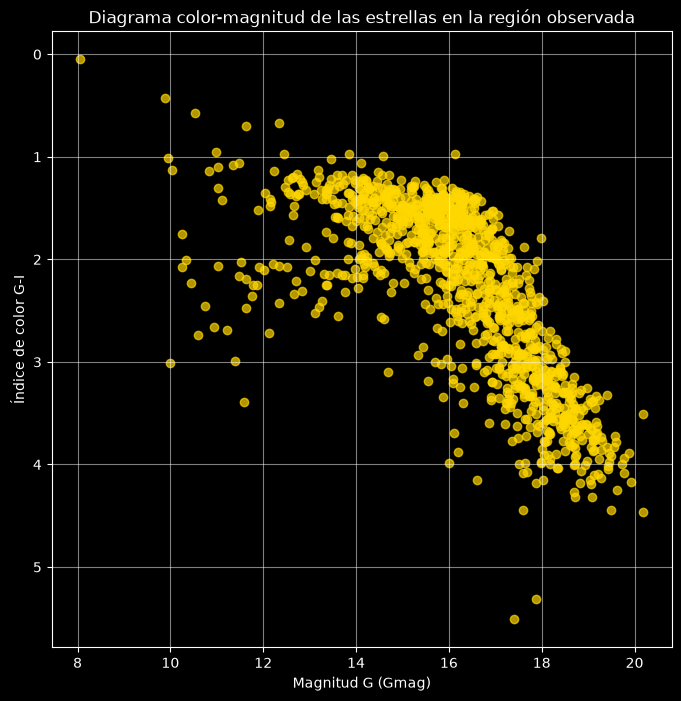

In [20]:
plt.style.use('dark_background')

plt.figure(figsize=(8,8))
plt.scatter(df_limpio['Gmag'], df_limpio['color_index'], color='gold', alpha =0.7)
plt.title("Diagrama color-magnitud de las estrellas en la región observada")
plt.gca().invert_yaxis()
plt.xlabel("Magnitud G (Gmag)")
plt.ylabel("Índice de color G-I")
plt.grid(alpha=0.5)
plt.show()

## **Cruce de tablas:**

Cargamos la tabla analizada del SDSS.

In [21]:
datos_cuasares = pd.read_csv('sdss_data.csv', skiprows=1)

datos_cuasares

,class,z,ra,dec,u,g
0,GALAXY,0.520906,135.70602,0.816696,20.85746,20.74581
1,GALAXY,0.513823,135.73529,0.797747,24.02483,22.56098
2,GALAXY,0.131484,135.86525,0.688536,19.46726,18.34731
3,STAR,0.000482,135.75656,0.168106,22.46362,21.45941
4,GALAXY,0.724637,135.38211,0.916066,24.23999,22.99065
...,...,...,...,...,...,...
247,GALAXY,0.542843,135.59061,0.850216,27.28441,22.32103
248,GALAXY,0.409645,135.57679,0.035218,24.92165,20.95431
249,STAR,0.000904,135.81715,0.333824,22.37484,21.25780
250,STAR,0.000296,135.64524,0.623502,24.58497,22.41142


Separamos cuásares de galaxias.

In [22]:
cuasares = datos_cuasares[datos_cuasares['class'] == 'QSO']
galaxias = datos_cuasares[datos_cuasares['class'] == 'GALAXY']

La función `cercaina`, mide una distancia.

In [23]:
def cercania(coords1, coords2):
    R = np.sqrt((coords1[0] - coords2[0])**2 + (coords1[1] - coords2[1])**2)
    return R

Aquí hacemos los matches, donde verificaremos si los objetos son cercanos con una tolerancia de $\text{tol} = 2'$

In [24]:
matches = np.zeros(len(df_limpio['RA_ICRS']))

for i in range(len(df_limpio['RA_ICRS'])):
    for j in range(len(datos_cuasares['ra'])):
        cord1 = np.array([df_limpio['RA_ICRS'].iloc[i], df_limpio['DE_ICRS'].iloc[i]])
        cord2 = np.array([datos_cuasares['ra'].iloc[j], datos_cuasares['dec'].iloc[j]])

        tol = 2/60

        if cercania(cord1, cord2) <= tol:
            matches[i] = True

Aplicamos una máscara para ver qué datos **no** coinciden en posición.

In [25]:
mask_cssmt = (matches == 0)
mask_cssmt

array([False, False,  True, ...,  True,  True,  True], shape=(1205,))

Este es el mapa de nuestros objetos en esa región del cielo.

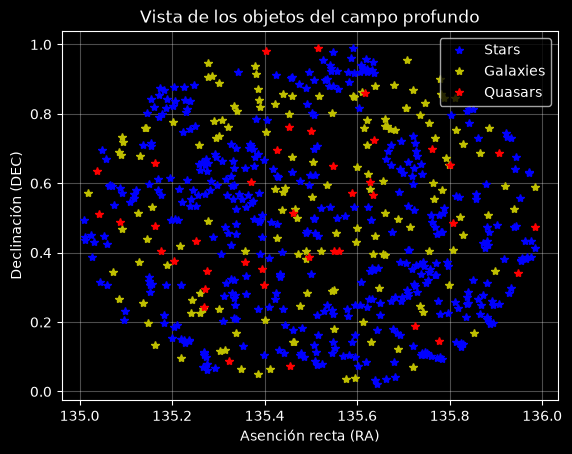

In [26]:
plt.plot(df_limpio['RA_ICRS'][mask_cssmt], df_limpio['DE_ICRS'][mask_cssmt], 'b*', label='Stars')
#plt.plot(df_limpio['RA_ICRS'], df_limpio['DE_ICRS'], 'g*')
plt.plot(galaxias['ra'], galaxias['dec'], 'y*', label='Galaxies')
plt.plot(cuasares['ra'], cuasares['dec'], 'r*', label='Quasars')
plt.title('Vista de los objetos del campo profundo')
plt.legend(loc='best')
plt.xlabel('Asención recta (RA)')
plt.ylabel('Declinación (DEC)')
plt.grid(alpha=0.3)
plt.show()

## **Conclusiones**

Para distinguir entre una estrella cercana o un objeto lejano una herramienta fundamental es el paralaje que consideramos en la consulta a GAIA. Entre menor sea el paralaje indicará que el objeto está a una distancia mayor, así como el movimiento propio, si este es poco apreciable. Por el contrario si el movimiento propio es considerable o el paralaje es grande, puede entonces ser que el objeto sea más bien local.

En este trabajo se analizó entonces la población del cúmulo del campo profundo de la región $(135.5°, 0.5°)$ (en asención recta y declinación), el cual estaba permeado por objetos cercanos y lejandos. Analizando el paralaje miramos cuáles objetos eran distantes y los descartamos, así como aquellos que su incertidumbre era grande para este número. Además, el movimiento propio nos permitió determinar las estrellas del cúmulo, que están en el diagrama colo-magnitud anterior, donde descartamos aquellas que eran más cercanas a La Tierra.

Cabe resaltar que las estrellas de este cúmulo (aunque no se cuente con la suficiente formación en astrofísica estelar aún), son estrellas que para su índice de color están en la secuencia principal la mayoría de ellas. Muchas son anaranjadas, amarillas o rojas, el cúmulo no tiene tanta presencia de estrellas azules. Esto es un indicador, no definitivo, de que las estrellas de este cúmulo pueden ser poco masivas, en especial para las que están en la cola inferior donde la secuencia principal abraza las estrellas más rojas.